Run this code in "napari" environment! 

In [2]:
import mrcfile
import numpy as np
import os

In [3]:
data_path = "../data/Chestnut_Jove_2024_article/Tomograms/73.mrc"
mask_path = "../data/Chestnut_Jove_2024_article/Segmentation_allmembranes/73_seg.mrc"

In [4]:
with mrcfile.open(data_path, permissive=True) as mrc:
    data = mrc.data
    # Access header information
    print("Data shape:", mrc.data.shape)  # Dimensions of the data
    print("Voxel size (angstroms):", mrc.voxel_size)  # Voxel size if available
    print("Map origin:", mrc.header.origin)  # Origin of the map
    print("Pixel spacing:", mrc.voxel_size)  # Pixel spacing for each axis
    print("Minimum and maximum density:", mrc.header.dmin, mrc.header.dmax)
    print("Mean density:", mrc.header.dmean)

    # Other specific header fields
    print("Number of columns, rows, and sections:", mrc.header.nx, mrc.header.ny, mrc.header.nz)
    print("Data mode:", mrc.header.mode)  # Data type (e.g., byte, float)
    print("Cell dimensions (angstroms):", mrc.header.cella)  # Cell dimensions
    print("Cell angles:", mrc.header.cellb)  # Cell angles

Data shape: (794, 1632, 1160)
Voxel size (angstroms): (16.0, 16.0, 16.0)
Map origin: (0.0, 0.0, 0.0)
Pixel spacing: (16.0, 16.0, 16.0)
Minimum and maximum density: -18.686468 8.098543
Mean density: -0.47542518
Number of columns, rows, and sections: 1160 1632 794
Data mode: 2
Cell dimensions (angstroms): (18560.0, 26112.0, 12704.0)
Cell angles: (90.0, 90.0, 90.0)


In [5]:
with mrcfile.open(mask_path, permissive=True) as mrc_mask:
    data_mask = mrc_mask.data
    # Access header information
    print("Data shape:", mrc_mask.data.shape)  # Dimensions of the data
    print("Voxel size (angstroms):", mrc_mask.voxel_size)  # Voxel size if available
    print("Map origin:", mrc_mask.header.origin)  # Origin of the map
    print("Pixel spacing:", mrc_mask.voxel_size)  # Pixel spacing for each axis
    print("Minimum and maximum density:", mrc_mask.header.dmin, mrc_mask.header.dmax)
    print("Mean density:", mrc_mask.header.dmean)

    # Other specific header fields
    print("Number of columns, rows, and sections:", mrc_mask.header.nx, mrc_mask.header.ny, mrc_mask.header.nz)
    print("Data mode:", mrc_mask.header.mode)  # Data type (e.g., byte, float)
    print("Cell dimensions (angstroms):", mrc_mask.header.cella)  # Cell dimensions
    print("Cell angles:", mrc_mask.header.cellb)  # Cell angles

Data shape: (794, 1632, 1160)
Voxel size (angstroms): (16.0, 16.0, 16.0)
Map origin: (0.0, 0.0, 0.0)
Pixel spacing: (16.0, 16.0, 16.0)
Minimum and maximum density: -128.0 127.0
Mean density: -127.080246
Number of columns, rows, and sections: 1160 1632 794
Data mode: 2
Cell dimensions (angstroms): (18560.0, 26112.0, 12704.0)
Cell angles: (90.0, 90.0, 90.0)


In [6]:
# function that visualizes mrc data in napari
import napari

def napari_view(data, mask):
    viewer = napari.Viewer()
    viewer.add_image(data, name='tomogram', colormap='gray', blending='additive')
    if mask is not None:
        viewer.add_image(mask, name='mask', colormap='red', blending='additive', opacity=0.5)
    napari.run()

In [18]:
napari_view(data, data_mask)

In [22]:
# Crop data

import skimage.measure
import numpy as np
from skimage.transform import resize

# Define crop range in z, y, x
z_start, z_end = 373, 437  
y_start, y_end = 400, 464
x_start, x_end = 555, 619

# Crop the cryo-ET data
cropped_data = data[z_start:z_end, y_start:y_end, x_start:x_end]
cropped_mask = data_mask[z_start:z_end, y_start:y_end, x_start:x_end]

In [23]:
print(cropped_data.shape)
print(cropped_mask.shape)

(64, 64, 64)
(64, 64, 64)


In [25]:
napari_view(cropped_data, cropped_mask)

In [26]:
# Save cropped data
data_output = cropped_data
mask_output = cropped_mask

output_data_path = "../data/Chestnut_Jove_2024_downsampled/73_64.mrc"
output_mask_path = "../data/Chestnut_Jove_2024_downsampled/73_64_mask.mrc"

with mrcfile.new(output_data_path, overwrite=True) as mrc:
    mrc.set_data(data_output.astype(np.float32))

with mrcfile.new(output_mask_path, overwrite=True) as mrc:
    mrc.set_data(mask_output.astype(np.float32))

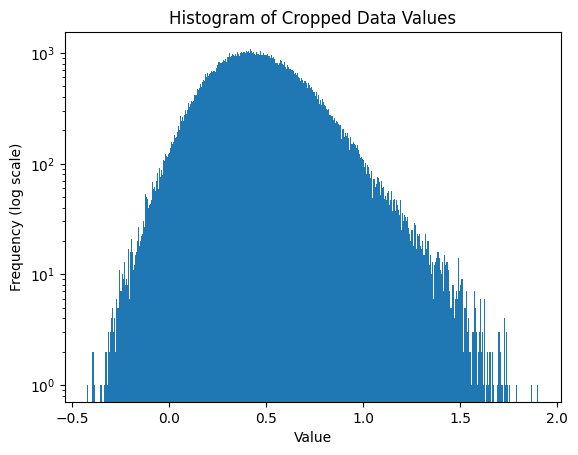

In [27]:
# Normalize data

# Before normalization, check the distribution of values using mean and std and visualize with histogram
import matplotlib.pyplot as plt
import numpy as np
import mrcfile

# Reopen cropped data from mrc file
output_data_path = "../data/Chestnut_Jove_2024_downsampled/73_64.mrc"
with mrcfile.open(output_data_path, permissive=True) as mrc:
    cropped_data = mrc.data

# Flipp the data by -1
cropped_data = -cropped_data

plt.hist(cropped_data.ravel(), bins=1000)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Cropped Data Values')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

In [25]:
napari_view(cropped_data, None)

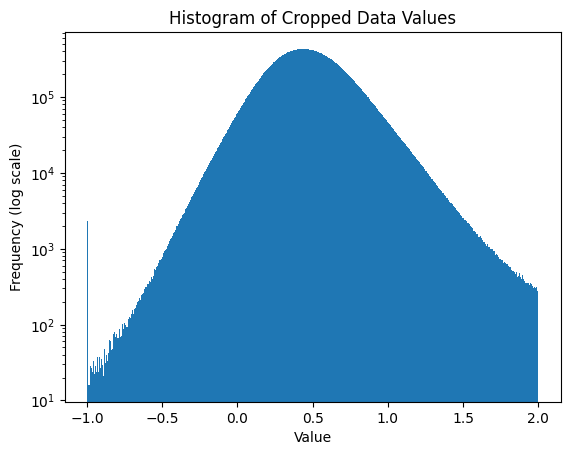

In [ ]:
# Clean up extreme values by clipping if necessary

# Most data ranges between -0.9 to 2.5, so we set the outliers into 0
cropped_remove_extreme = np.clip(cropped_data, -1, 2)

plt.hist(cropped_remove_extreme.ravel(), bins=1000)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Cropped Data Values')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

In [37]:
napari_view(cropped_remove_extreme, None)

In [ ]:
import jax
import jax.numpy as jnp

# Set the range for normalization
norm_min, norm_max = 0.0, 1.0

# Normalize data so that the values are between 0 and 1
data_min = np.min(cropped_data)
data_max = np.max(cropped_data)

print("Data min:", data_min)
print("Data max:", data_max)

# You want membrane regions to be 1 and non-membrane regions to be 0
normalized_data = (cropped_remove_extreme - data_min) / (data_max - data_min)
normalized_data = normalized_data * (norm_max - norm_min) + norm_min
print("Normalized data min:", np.min(normalized_data))
print("Normalized data max:", np.max(normalized_data))
napari_view(normalized_data, None)
normalized_data = jnp.asarray(normalized_data, dtype=jnp.float32)